# <center>        **Machine Learning -ASSIGNMENT 2**</center>
## **Binary Classification problem Prediction with 5 Models(Credit Card Defaulter Prediction)**

### Problem Statement

The objective of this analysis is to predict whether a credit card client in Taiwan will default on their payment in the upcoming month based on their demographic details, credit limit, and 6-month historical repayment trends.

Input features
* Credit Limit
* Demographics(Sex,Education,Marriage,Age)
* Past Repayment Status
* Bill Statement Amounts
* Previous Payments Made

Output/Target feature
* Default payment in next month(0:Client will not default, 1: Client will default)

In [3]:
!pip install xlrd

In [4]:
# Installing the packages

import pandas as pd
import numpy as np
import io
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
import os
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.max_info_columns',50)

In [5]:
# Pulling the Data from UCI Credit Card Dataset using URL
import urllib.request

INPUT_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
INPUT_FILE = "../default_credit_card_clients.xls"

if not os.path.exists(INPUT_FILE):
    print("Retrieving Credit Card Defaulter Dataset from UCI Portal")
    urllib.request.urlretrieve(INPUT_URL, INPUT_FILE)
    print("Download Completed")
else:
    print("Input excel file already downloaded")

Retrieving Credit Card Defaulter Dataset from UCI Portal
Download Completed


In [6]:
# read the data from excel file
df_input = pd.read_excel(INPUT_FILE, header=1)

# First 5 rows of the input dataset
print("First 5 records input dataset: ")
df_input.head()

First 5 records input dataset: 


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [7]:
# Data Size
print('Size of the Input dataset : ',df_input.shape)

Size of the Input dataset :  (30000, 25)


In [8]:
# Column names and none null value counts in input dataset
print('Column names and none null value counts Input Dataset: ')
df_input.info()

Column names and none null value counts Input Dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_

In [9]:
print('Statistical information, description and statistical summary of the input data : ')
print('\n')
df_input.describe(include='all')

Statistical information, description and statistical summary of the input data : 




,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [10]:
#--Duplicate Data
print("Duplicate record count : ",df_input.duplicated().sum())

Duplicate record count :  0


In [11]:
def get_categorical_breakdown(df, col_name, mapping=None):
    # Calculate counts and percentages
    counts = df[col_name].value_counts().reset_index()
    counts.columns = [col_name, 'Record Count']
    counts['Percentage (%)'] = (counts['Record Count'] / len(df) * 100).round(2)

    # Map friendly names if a dictionary is provided
    if mapping:
        counts['Meaning'] = counts[col_name].map(mapping)
        counts = counts[[col_name, 'Meaning', 'Record Count', 'Percentage (%)']]

    return counts

# List of categorical columns to inspect
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'default payment next month']

for col in cat_cols:
    print(f"=== {col} Breakdown ===")
    display(get_categorical_breakdown(df_input, col))
    print("\n")

=== SEX Breakdown ===


,SEX,Record Count,Percentage (%)
0,2,18112,60.37
1,1,11888,39.63




=== EDUCATION Breakdown ===


,EDUCATION,Record Count,Percentage (%)
0,2,14030,46.77
1,1,10585,35.28
2,3,4917,16.39
3,5,280,0.93
4,4,123,0.41
5,6,51,0.17
6,0,14,0.05




=== MARRIAGE Breakdown ===


,MARRIAGE,Record Count,Percentage (%)
0,2,15964,53.21
1,1,13659,45.53
2,3,323,1.08
3,0,54,0.18




=== default payment next month Breakdown ===


,default payment next month,Record Count,Percentage (%)
0,0,23364,77.88
1,1,6636,22.12


#### <b>Observation</b>
* All columns have 30,000 entries, confirming there are no missing values in the dataset
* There is no duplicate records in the dataset
* All the features are in integer format
* Target Variable (default payment next month): only 22.12% of the customers in this dataset defaulted on their payments, highlighting a class imbalance
* As per the accepatble values in source dataset in <b>UCI</b>, categorical fields has very few erroneous which are outside acceptable range - Marriage(0 with 0.18%), Education(0,5,6 -1.15%). These incorrect data need to be dropped before processing.

In [13]:
# Deleting the incorrect value records
df_input = df_input[df_input['MARRIAGE'] != 0]
df_input = df_input[df_input['EDUCATION'] != 0]
df_input = df_input[df_input['EDUCATION'] != 5]
df_input = df_input[df_input['EDUCATION'] != 6]
df_input.shape

(29601, 25)

### <b> Visualize relationships between key features</b>

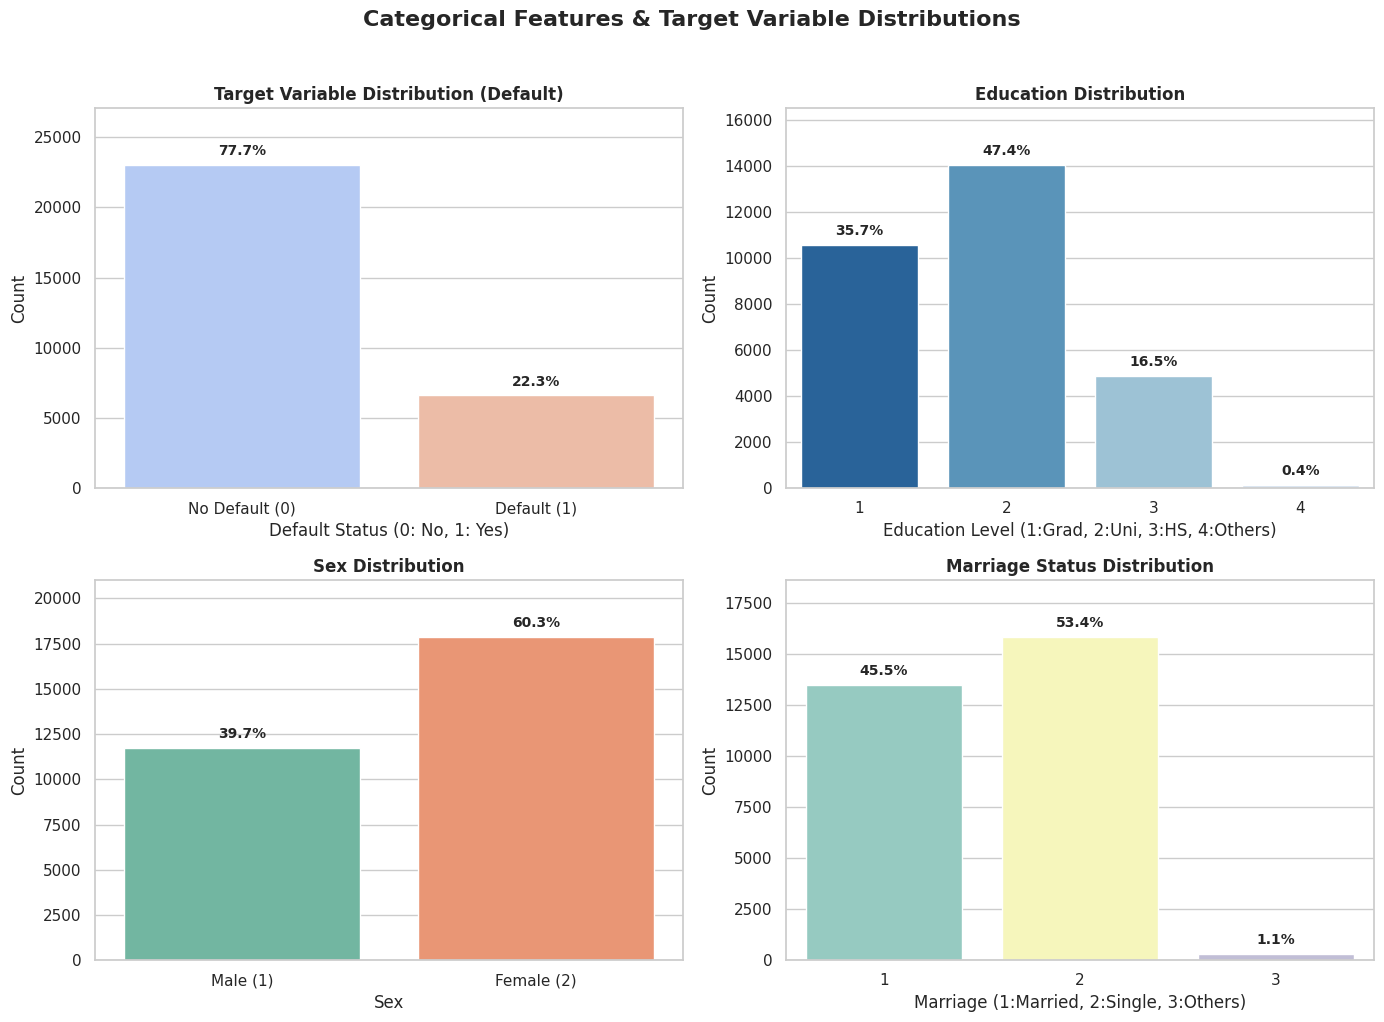

In [15]:
# Set overall plot aesthetic style
sns.set_theme(style="whitegrid")

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Variable Distribution
ax1 = axes[0, 0]
sns.countplot(
    ax=ax1,
    x="default payment next month",
    data=df_input,
    palette="coolwarm"
)
ax1.set_title("Target Variable Distribution (Default)", fontsize=12, weight="bold")
ax1.set_xlabel("Default Status (0: No, 1: Yes)")
ax1.set_ylabel("Count")
ax1.set_xticklabels(["No Default (0)", "Default (1)"])

# 2. Education Distribution
ax2 = axes[0, 1]
sns.countplot(ax=ax2, x="EDUCATION", data=df_input, palette="Blues_r")
ax2.set_title("Education Distribution", fontsize=12, weight="bold")
ax2.set_xlabel("Education Level (1:Grad, 2:Uni, 3:HS, 4:Others)")
ax2.set_ylabel("Count")

# 3. Sex Distribution
ax3 = axes[1, 0]
sns.countplot(ax=ax3, x="SEX", data=df_input, palette="Set2")
ax3.set_title("Sex Distribution", fontsize=12, weight="bold")
ax3.set_xlabel("Sex")
ax3.set_ylabel("Count")
ax3.set_xticklabels(["Male (1)", "Female (2)"])

# 4. Marriage Distribution
ax4 = axes[1, 1]
sns.countplot(ax=ax4, x="MARRIAGE", data=df_input, palette="Set3")
ax4.set_title("Marriage Status Distribution", fontsize=12, weight="bold")
ax4.set_xlabel("Marriage (1:Married, 2:Single, 3:Others)")
ax4.set_ylabel("Count")

# --- ADD PERCENTAGES TO ALL BARS ---
total_records = len(df_input)

for ax in axes.flat:
    # Set y-limit higher to make room for text above bars
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = (height / total_records) * 100
            # Annotate with percentage (e.g., "53.2%")
            ax.annotate(
                f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=10,
                fontweight='bold'
            )

plt.suptitle("Categorical Features & Target Variable Distributions", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

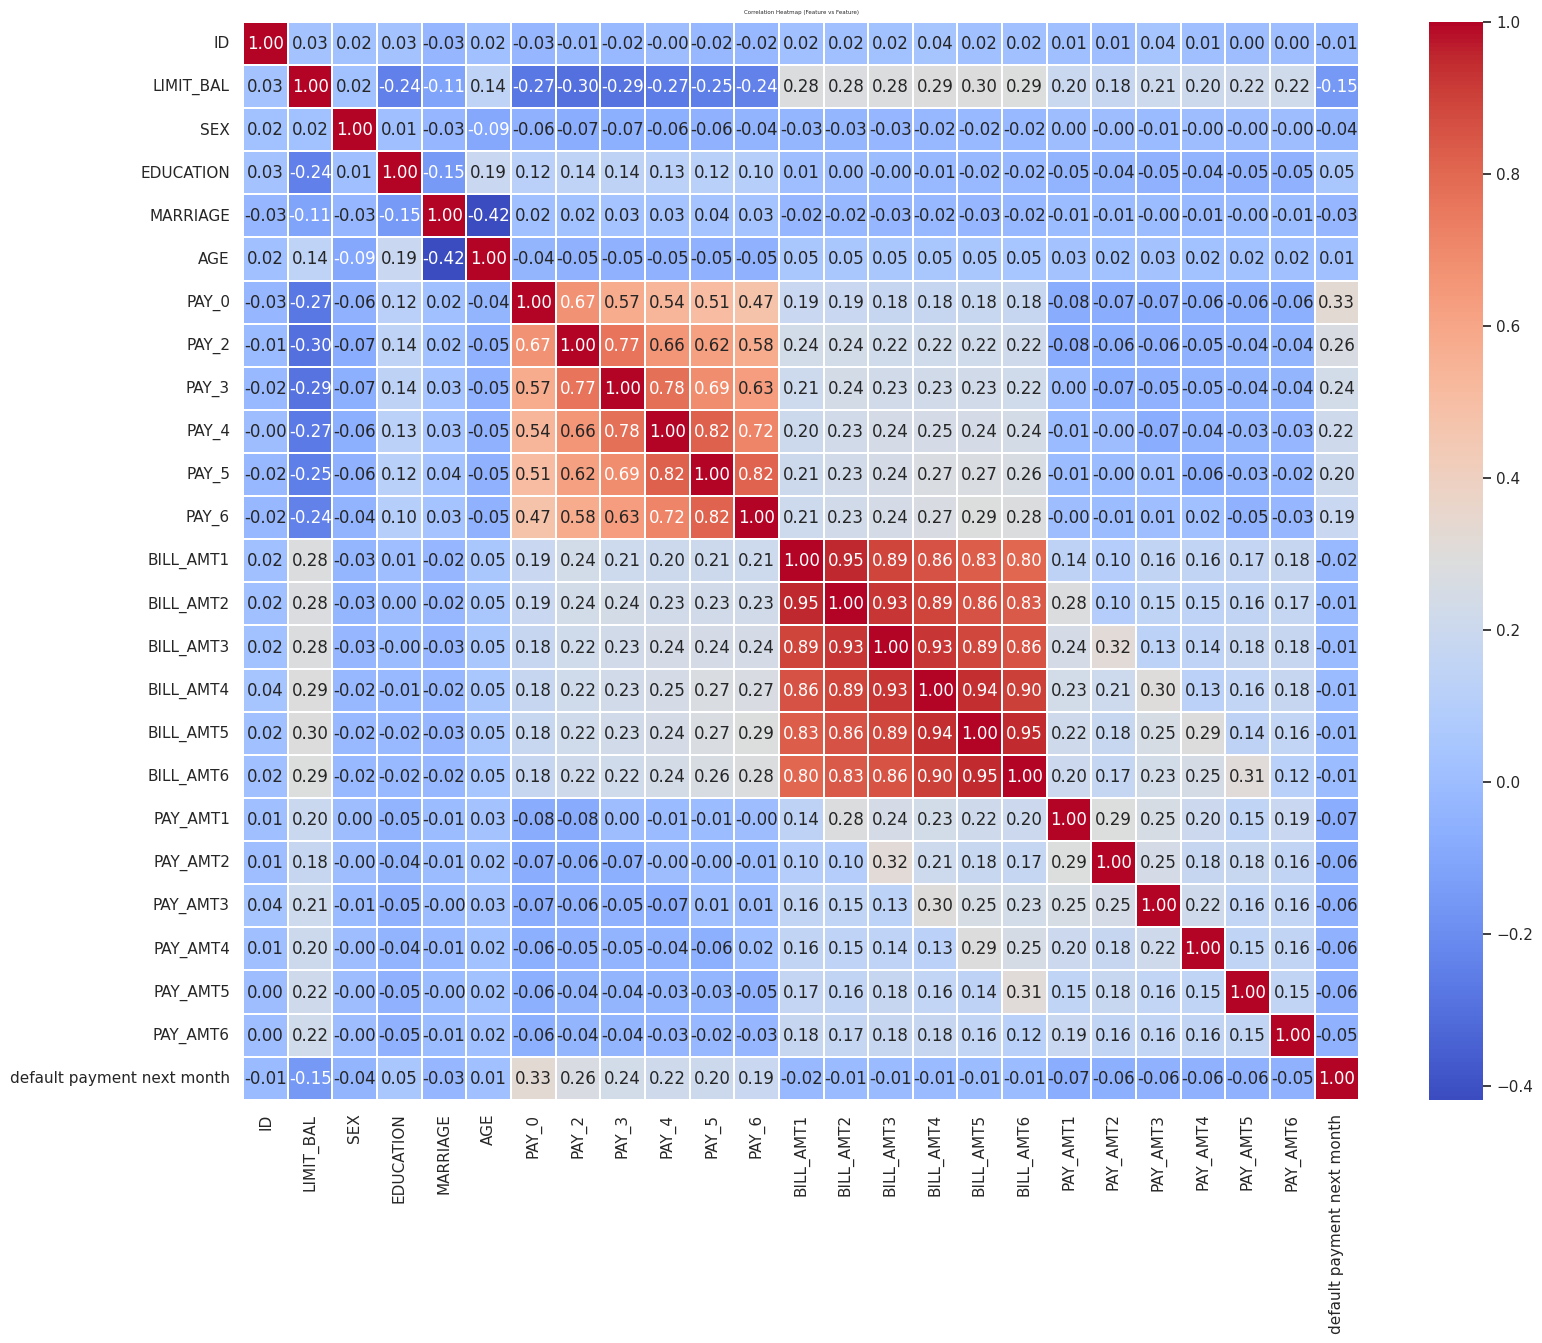

In [16]:
# --- Visual: Correlation Heatmap ---
plt.figure(figsize=(18, 14))

numerical_df = df_input.select_dtypes(include=['number'])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.3)
plt.title("Correlation Heatmap (Feature vs Feature)", fontsize=4)
plt.show()

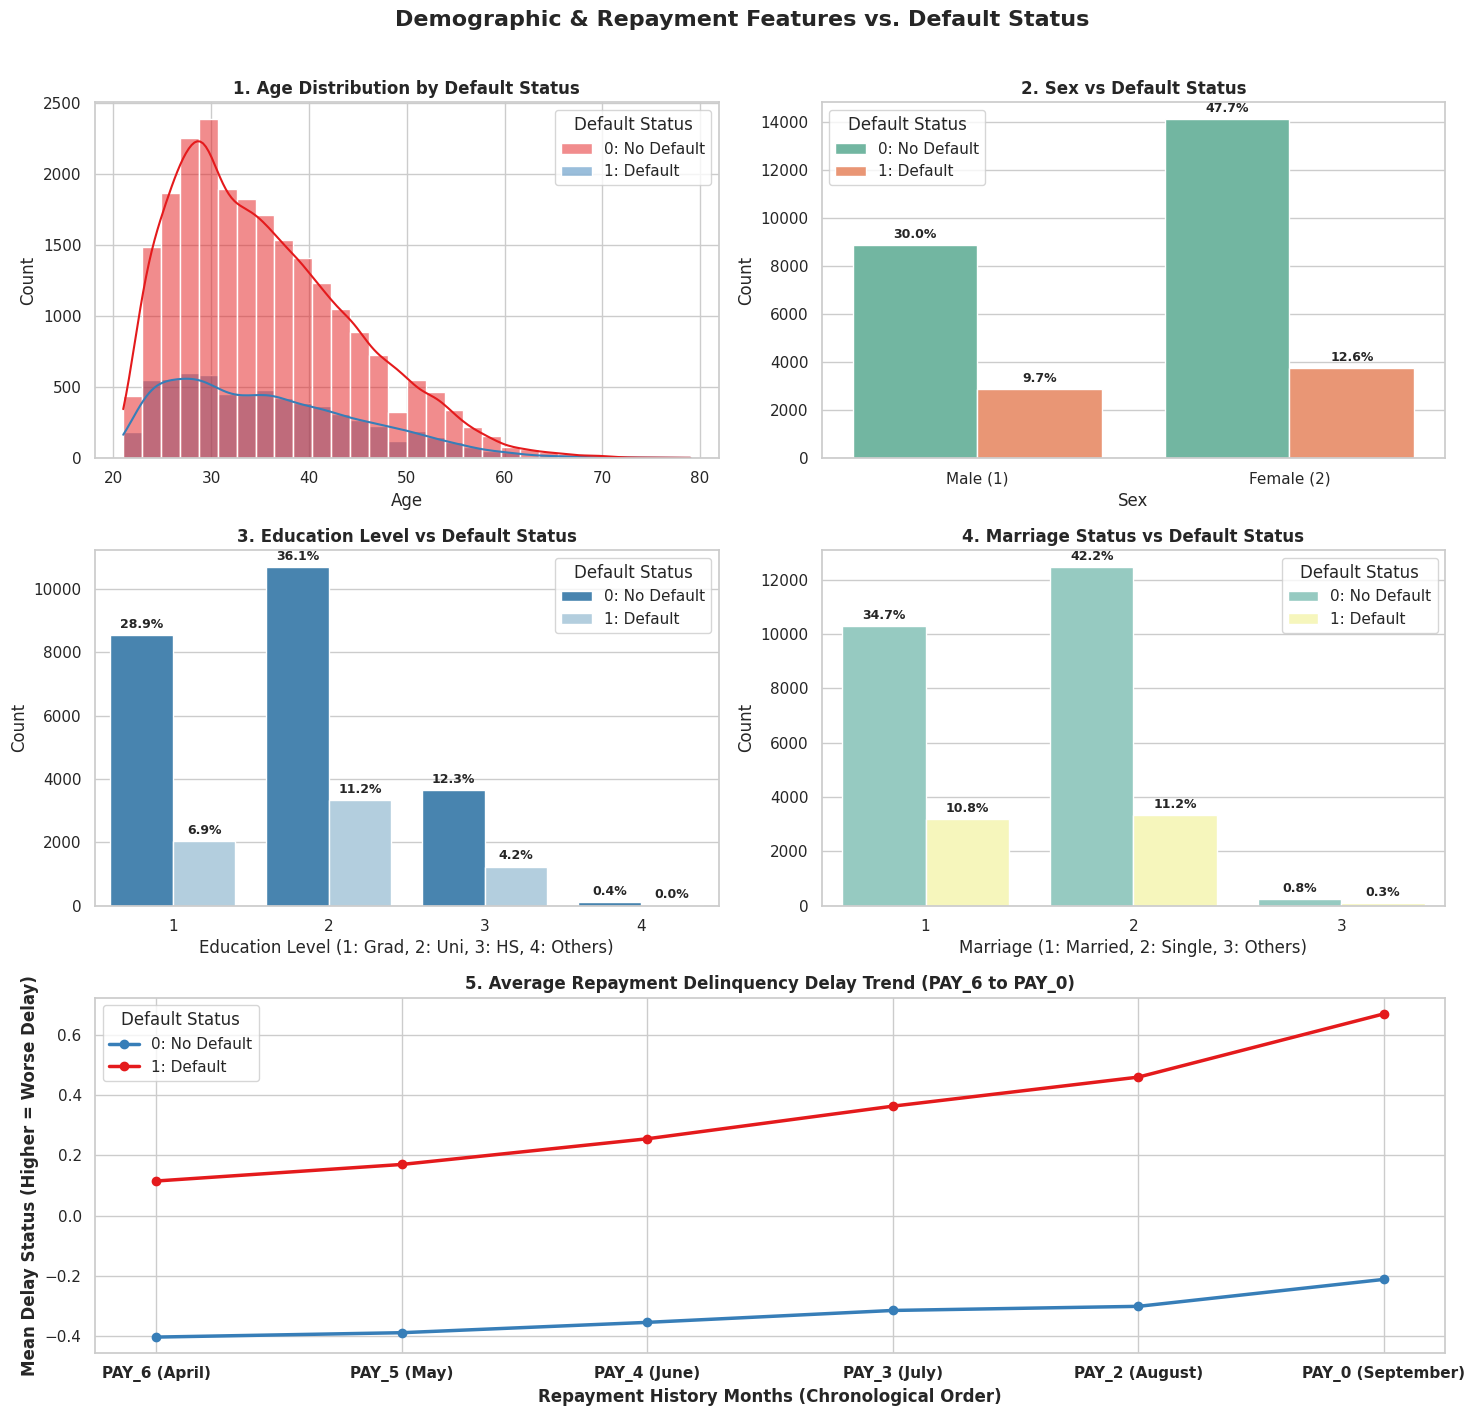

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set overall aesthetic style
sns.set_theme(style="whitegrid")

# Create a 3x2 grid layout for all 5 plots
fig, axes = plt.subplots(3, 2, figsize=(15, 14))

# Target hue order
hue_order = [0, 1]
total = len(df_input)

# -------------------------------------------------------------------------
# 1. Age vs Default (KDE / Histogram)
# -------------------------------------------------------------------------
ax1 = axes[0, 0]
sns.histplot(
    data=df_input,
    x="AGE",
    hue="default payment next month",
    hue_order=hue_order,
    kde=True,
    bins=30,
    palette="Set1",
    ax=ax1,
)
ax1.set_title("1. Age Distribution by Default Status", fontsize=12, fontweight="bold")
ax1.set_xlabel("Age")
ax1.set_ylabel("Count")

legend1 = ax1.get_legend()
if legend1:
    legend1.set_title("Default Status")
    for t in legend1.get_texts():
        t.set_text("0: No Default" if t.get_text() == "0" else "1: Default")

# -------------------------------------------------------------------------
# 2. Sex vs Default (Countplot)
# -------------------------------------------------------------------------
ax2 = axes[0, 1]
sns.countplot(
    data=df_input,
    x="SEX",
    hue="default payment next month",
    hue_order=hue_order,
    palette="Set2",
    ax=ax2,
)
ax2.set_title("2. Sex vs Default Status", fontsize=12, fontweight="bold")
ax2.set_xlabel("Sex")
ax2.set_ylabel("Count")
ax2.set_xticklabels(["Male (1)", "Female (2)"])

legend2 = ax2.get_legend()
if legend2:
    legend2.set_title("Default Status")
    for t in legend2.get_texts():
        t.set_text("0: No Default" if t.get_text() == "0" else "1: Default")

for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.annotate(
            f"{(height/total)*100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
        )

# -------------------------------------------------------------------------
# 3. Education vs Default (Countplot)
# -------------------------------------------------------------------------
ax3 = axes[1, 0]
sns.countplot(
    data=df_input,
    x="EDUCATION",
    hue="default payment next month",
    hue_order=hue_order,
    palette="Blues_r",
    ax=ax3,
)
ax3.set_title("3. Education Level vs Default Status", fontsize=12, fontweight="bold")
ax3.set_xlabel("Education Level (1: Grad, 2: Uni, 3: HS, 4: Others)")
ax3.set_ylabel("Count")

legend3 = ax3.get_legend()
if legend3:
    legend3.set_title("Default Status")
    for t in legend3.get_texts():
        t.set_text("0: No Default" if t.get_text() == "0" else "1: Default")

for p in ax3.patches:
    height = p.get_height()
    if height > 0:
        ax3.annotate(
            f"{(height/total)*100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
        )

# -------------------------------------------------------------------------
# 4. Marriage vs Default (Countplot)
# -------------------------------------------------------------------------
ax4 = axes[1, 1]
sns.countplot(
    data=df_input,
    x="MARRIAGE",
    hue="default payment next month",
    hue_order=hue_order,
    palette="Set3",
    ax=ax4,
)
ax4.set_title("4. Marriage Status vs Default Status", fontsize=12, fontweight="bold")
ax4.set_xlabel("Marriage (1: Married, 2: Single, 3: Others)")
ax4.set_ylabel("Count")

legend4 = ax4.get_legend()
if legend4:
    legend4.set_title("Default Status")
    for t in legend4.get_texts():
        t.set_text("0: No Default" if t.get_text() == "0" else "1: Default")

for p in ax4.patches:
    height = p.get_height()
    if height > 0:
        ax4.annotate(
            f"{(height/total)*100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
        )

# -------------------------------------------------------------------------
# 5. Average Repayment Delinquency Delay Trend (PAY_6 to PAY_0)
# -------------------------------------------------------------------------
# Combine the 5th and 6th slots into one full-width subplot
fig.delaxes(axes[2, 0])
fig.delaxes(axes[2, 1])
ax5 = fig.add_subplot(3, 1, 3)

# Chronological order from PAY_6 (April) to PAY_0 (September)
pay_cols_chrono = ["PAY_6", "PAY_5", "PAY_4", "PAY_3", "PAY_2", "PAY_0"]
pay_means = df_input.groupby("default payment next month")[pay_cols_chrono].mean().T

# Custom x-axis tick labels with months explicitly included
custom_x_labels = [
    "PAY_6 (April)",
    "PAY_5 (May)",
    "PAY_4 (June)",
    "PAY_3 (July)",
    "PAY_2 (August)",
    "PAY_0 (September)",
]

ax5.plot(
    pay_means.index,
    pay_means[0],
    marker="o",
    linewidth=2.5,
    color="#377eb8",
    label="0: No Default",
)
ax5.plot(
    pay_means.index,
    pay_means[1],
    marker="o",
    linewidth=2.5,
    color="#e41a1c",
    label="1: Default",
)

ax5.set_xticks(range(len(pay_cols_chrono)))
ax5.set_xticklabels(custom_x_labels, fontweight="bold")

ax5.set_title(
    "5. Average Repayment Delinquency Delay Trend (PAY_6 to PAY_0)",
    fontsize=12,
    fontweight="bold",
)
ax5.set_xlabel("Repayment History Months (Chronological Order)", fontweight="bold")
ax5.set_ylabel("Mean Delay Status (Higher = Worse Delay)", fontweight="bold")
ax5.legend(title="Default Status", loc="upper left")

plt.suptitle("Demographic & Repayment Features vs. Default Status", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### <b> Observations </b>

* LIMIT_BAL shows a slight negative correlationwith default which signifies Clients with higher credit limits are slightly less likely to default
* There is an extremely strong positive correlation among all bill amount features (BILL_AMT1 to BILL_AMT6).Because these features carry redundant information, linear models (like Logistic Regression) may suffer from multicollinearity, so need to drop BILL_AMT2-6 for better results.
* Repayment Status(PAY_0 to PAY_6) features show the strongest positive correlation with the target variable (default payment next month), with PAY_0 (recent payment status) having the highest positive correlation.
* Both defaulters and non-defaulters peak between ages 25 and 35, making younger clients the largest overall user demographic. While account volume decreases sharply past age 50, the proportion of defaults relative to group size remains fairly consistent across ages.
* Female clients represent a larger overall proportion of cardholders compared to male clients. However, male clients show a slightly higher relative rate of default within their group size.
* University-educated clients (Level 2) account for the highest default volume at 11.2% of all records, followed by Graduate School clients (Level 1) at 6.9%. Overall, graduate-level clients demonstrate a lower relative default risk compared to university or high school graduates.
* Single and married clients constitute almost the entire dataset, with single individuals holding the highest share of accounts. Married clients display a marginally higher rate of default relative to their total volume compared to single clients.
* Non-defaulters consistently maintain zero or negative payment delay scores from April (PAY_6) to September (PAY_0), indicating on-time payments. Conversely, defaulters show a steadily escalating delay trend over the 6-month period, spiking sharply at recent payment status (PAY_0).

### Train Test Split

In [20]:
# Separate the target column
target_col = "default payment next month"
X = df_input.drop(columns=[target_col])
y = df_input[target_col]

In [21]:
from sklearn.model_selection import train_test_split

# Train/Test split - Stratification used to handle class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Storing the Test data in CSV format for Streamlit App

In [23]:
# Save test data - will be used in streamlit app as default file
test_df = X_test.copy()
test_df[target_col] = y_test.values
test_df.to_csv("../test_data.csv", index=False)
print(f"test_data.csv saved with ({len(test_df)} rows)")

test_data.csv saved with (5921 rows)


### Preprocessing & Feature Engineering

In [25]:
# Pre processing the data to remove features
X_train.drop(columns=["ID","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"],inplace=True)
X_test.drop(columns=["ID","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"],inplace=True)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((23680, 18), (5921, 18), (23680,), (5921,))

In [26]:
# Scaling the the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## <b> Machine Learning Classification models </b>

In [28]:
# Evaluation Parameters for Classification Models
import joblib
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)

# Defined to store the Evaluation results of the Models
evaluation_results = {}

1. <b>Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

Logistic_Regression = LogisticRegression(max_iter=1000, random_state=42)

print(f"\nModel training started for Logistic Regression")

Logistic_Regression.fit(X_train_scaled, y_train)
y_pred = Logistic_Regression.predict(X_test_scaled)
y_pred_proba = Logistic_Regression.predict_proba(X_test_scaled)[:, 1]

evaluation_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "AUC_Score": roc_auc_score(y_test, y_pred_proba),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1_Score": f1_score(y_test, y_pred),
    "MCC": matthews_corrcoef(y_test, y_pred)
    }

evaluation_results["Logistic Regression"] = evaluation_metrics

# Constructing Confusion Matrix
print(f"\nLogistic Regression model training completed. Confusion Matrix is")
print(confusion_matrix(y_test, y_pred))

print(f"\nAccuracy: {evaluation_metrics['Accuracy']:.4f} | AUC: {evaluation_metrics['AUC_Score']:.4f} | "
          f"F1_Score: {evaluation_metrics['F1_Score']:.4f} | MCC: {evaluation_metrics['MCC']:.4f}")


Model training started for Logistic Regression

Logistic Regression model training completed. Confusion Matrix is
[[4478  122]
 [1011  310]]

Accuracy: 0.8086 | AUC: 0.7232 | F1_Score: 0.3537 | MCC: 0.3332


In [31]:
# Saving model pickle files
filename = "logistic_regression.pkl"
logistic_regression_pipeline = Pipeline([
    ('scaler', scaler),
    ('model', Logistic_Regression)
])
joblib.dump(logistic_regression_pipeline, filename)
print(f"Saved Model pickle file : {filename}")

Saved Model pickle file : logistic_regression.pkl


2. <b>Decision Tree Classifier

In [33]:
from sklearn.tree import DecisionTreeClassifier

Decision_Tree_Classifier =  DecisionTreeClassifier(max_depth=10, random_state=42)

print(f"\nModel training started for Decision Tree Classifier")

Decision_Tree_Classifier.fit(X_train, y_train)
y_pred = Decision_Tree_Classifier.predict(X_test)
y_pred_proba = Decision_Tree_Classifier.predict_proba(X_test)[:, 1]

evaluation_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "AUC_Score": roc_auc_score(y_test, y_pred_proba),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1_Score": f1_score(y_test, y_pred),
    "MCC": matthews_corrcoef(y_test, y_pred)
    }

evaluation_results["Decision Tree Classifier"] = evaluation_metrics

# Constructing Confusion Matrix
print(f"\nDecision Tree Classifier model training completed. Confusion Matrix is")
print(confusion_matrix(y_test, y_pred))

print(f"\nAccuracy: {evaluation_metrics['Accuracy']:.4f} | AUC: {evaluation_metrics['AUC_Score']:.4f} | "
          f"F1_Score: {evaluation_metrics['F1_Score']:.4f} | MCC: {evaluation_metrics['MCC']:.4f}")


Model training started for Decision Tree Classifier

Decision Tree Classifier model training completed. Confusion Matrix is
[[4270  330]
 [ 807  514]]

Accuracy: 0.8080 | AUC: 0.7169 | F1_Score: 0.4748 | MCC: 0.3779


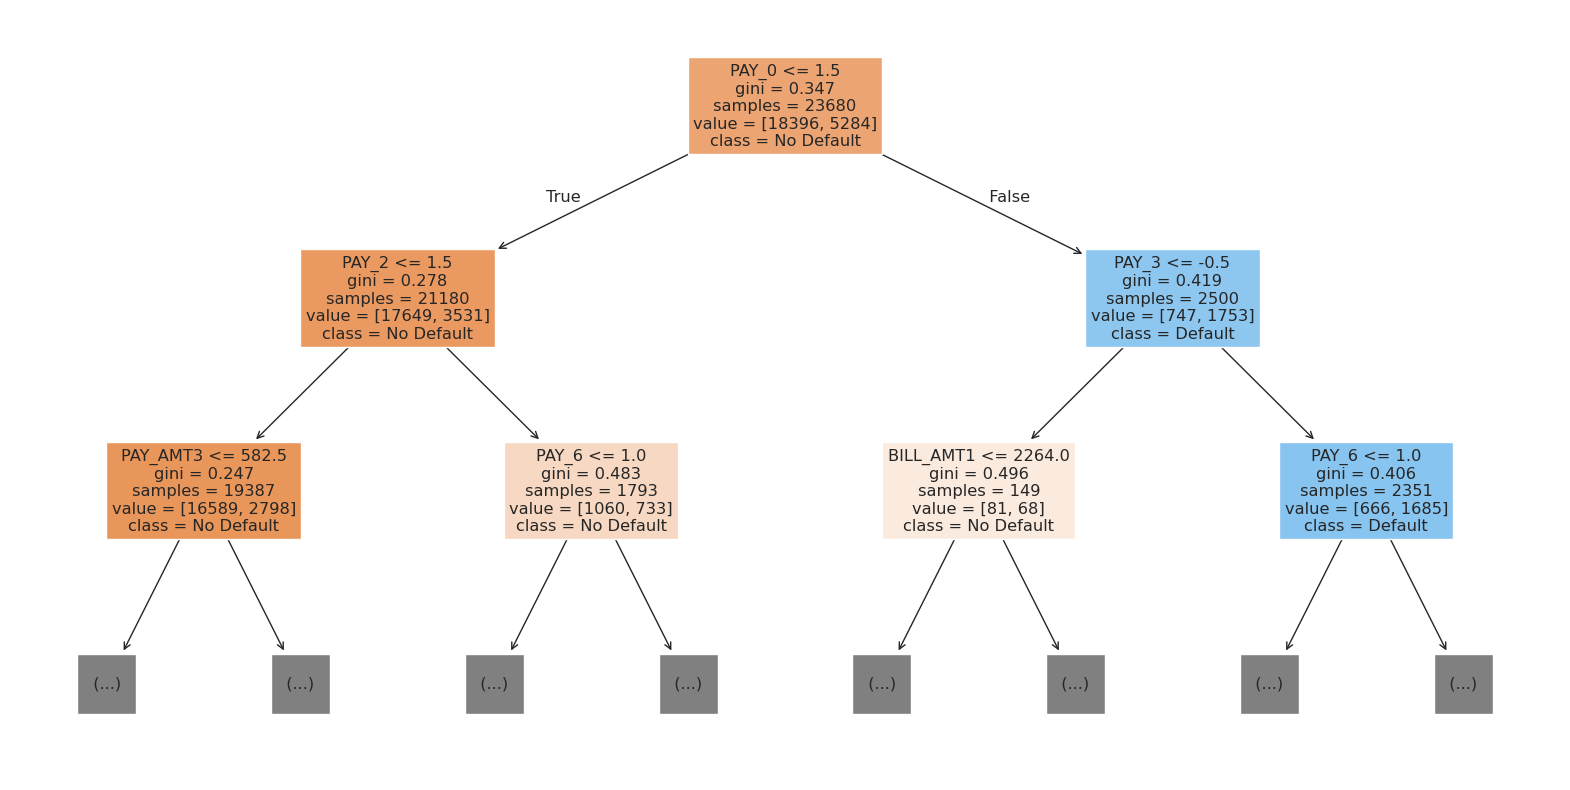

In [34]:
# Visualizing Decision Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    Decision_Tree_Classifier,
    feature_names=X_train.columns,
    class_names=["No Default", "Default"],
    filled=True,
    max_depth=2,  # Limits tree depth so the plot stays readable
)
plt.show()

In [35]:
# Saving model pickle files
filename = "decision_tree_classifier.pkl"
decision_tree_pipeline = Pipeline([
    ('model', Decision_Tree_Classifier)
])
joblib.dump(decision_tree_pipeline, filename)
print(f"Saved Model pickle file : {filename}")

Saved Model pickle file : decision_tree_classifier.pkl


3. <b> K-Nearest Neighbor Classifier

In [37]:
from sklearn.neighbors import KNeighborsClassifier

KNN_Classifier = KNeighborsClassifier(n_neighbors=10)

print(f"\nModel training started for KNN Classifier")

KNN_Classifier.fit(X_train_scaled, y_train)
y_pred = KNN_Classifier.predict(X_test_scaled)
y_pred_proba = KNN_Classifier.predict_proba(X_test_scaled)[:, 1]

evaluation_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "AUC_Score": roc_auc_score(y_test, y_pred_proba),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1_Score": f1_score(y_test, y_pred),
    "MCC": matthews_corrcoef(y_test, y_pred)
}
evaluation_results["KNN Classifier"] = evaluation_metrics

# Constructing Confusion Matrix
print(f"\nKNN Classifier model training completed. Confusion Matrix is")
print(confusion_matrix(y_test, y_pred))

print(f"\nAccuracy: {evaluation_metrics['Accuracy']:.4f} | AUC: {evaluation_metrics['AUC_Score']:.4f} | "
          f"F1_Score: {evaluation_metrics['F1_Score']:.4f} | MCC: {evaluation_metrics['MCC']:.4f}")


Model training started for KNN Classifier

KNN Classifier model training completed. Confusion Matrix is
[[4355  245]
 [ 924  397]]

Accuracy: 0.8026 | AUC: 0.7240 | F1_Score: 0.4045 | MCC: 0.3311


In [38]:
# Saving model pickle files
filename = "knn_classifier.pkl"
knn_classifier_pipeline = Pipeline([
    ('scaler', scaler),
    ('model', KNN_Classifier)
])
joblib.dump(knn_classifier_pipeline, filename)
print(f"Saved Model pickle file : {filename}")

Saved Model pickle file : knn_classifier.pkl


4. <b>Naive Bayes Classifier - Gaussian

In [40]:
from sklearn.naive_bayes import GaussianNB

Naive_Bayes_Classifier = GaussianNB()

print(f"\nModel training started for Naive Bayes Classifier")

Naive_Bayes_Classifier.fit(X_train, y_train)
y_pred = Naive_Bayes_Classifier.predict(X_test)
y_pred_proba = Naive_Bayes_Classifier.predict_proba(X_test)[:, 1]

evaluation_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "AUC_Score": roc_auc_score(y_test, y_pred_proba),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1_Score": f1_score(y_test, y_pred),
    "MCC": matthews_corrcoef(y_test, y_pred)
    }

evaluation_results["Naive Bayes Classifier"] = evaluation_metrics

# Constructing Confusion Matrix
print(f"\nNaive Bayes Classifier model training completed. Confusion Matrix is")
print(confusion_matrix(y_test, y_pred))

print(f"\nAccuracy: {evaluation_metrics['Accuracy']:.4f} | AUC: {evaluation_metrics['AUC_Score']:.4f} | "
          f"F1_Score: {evaluation_metrics['F1_Score']:.4f} | MCC: {evaluation_metrics['MCC']:.4f}")


Model training started for Naive Bayes Classifier

Naive Bayes Classifier model training completed. Confusion Matrix is
[[ 988 3612]
 [ 129 1192]]

Accuracy: 0.3682 | AUC: 0.6836 | F1_Score: 0.3892 | MCC: 0.1246


In [41]:
# Saving model pickle files
filename = "naive_bayes_classifier.pkl"
naive_bayes_pipeline = Pipeline([
    ('model', Naive_Bayes_Classifier)
])
joblib.dump(naive_bayes_pipeline, filename)
print(f"Saved Model pickle file : {filename}")

Saved Model pickle file : naive_bayes_classifier.pkl


5. <b>Ensemble Model - Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

Random_Forest = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

print(f"\nModel training started for Random Forest - Ensemble learning")

Random_Forest.fit(X_train, y_train)
y_pred = Random_Forest.predict(X_test)
y_pred_proba = Random_Forest.predict_proba(X_test)[:, 1]

evaluation_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "AUC_Score": roc_auc_score(y_test, y_pred_proba),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1_Score": f1_score(y_test, y_pred),
    "MCC": matthews_corrcoef(y_test, y_pred)
    }

evaluation_results["Random Forest"] = evaluation_metrics

# Constructing Confusion Matrix
print(f"\nRandom Forest model training completed. Confusion Matrix is")
print(confusion_matrix(y_test, y_pred))

print(f"\nAccuracy: {evaluation_metrics['Accuracy']:.4f} | AUC: {evaluation_metrics['AUC_Score']:.4f} | "
          f"F1_Score: {evaluation_metrics['F1_Score']:.4f} | MCC: {evaluation_metrics['MCC']:.4f}")


Model training started for Random Forest - Ensemble learning

Random Forest model training completed. Confusion Matrix is
[[4404  196]
 [ 844  477]]

Accuracy: 0.8244 | AUC: 0.7753 | F1_Score: 0.4784 | MCC: 0.4177


In [44]:
# Saving model pickle files
filename = "random_forest.pkl"
random_forest_pipeline = Pipeline([
    ('model', Random_Forest)
])
joblib.dump(Random_Forest, filename)
print(f"Saved Model pickle file : {filename}")

Saved Model pickle file : random_forest.pkl


### <b>Evaluation Table</b>

In [46]:
print("Classification Model Evaluation Metrics")
print("=" * 100)
print(f"{'|Model':<30} {'|'}{'Accuracy':<10}{'|'}{'AUC_Score':<10}{'|'}{'Precision':<10}"
      f"{'|Recall':<10} {'|'}{'F1_Score':<10}{'|'}{'MCC':<10}{'|'}")
print("-" * 100)
for name, metrics in evaluation_results.items():
    print(f"{'|'}{name:<30}{'|'}{metrics['Accuracy']:<10.4f}{'|'}{metrics['AUC_Score']:<10.4f}"
          f"{'|'}{metrics['Precision']:<10.4f}{'|'}{metrics['Recall']:<10.4f}"
          f"{'|'}{metrics['F1_Score']:<10.4f}{'|'}{metrics['MCC']:<10.4f}{'|'}")

Classification Model Evaluation Metrics
|Model                         |Accuracy  |AUC_Score |Precision |Recall    |F1_Score  |MCC       |
----------------------------------------------------------------------------------------------------
|Logistic Regression           |0.8086    |0.7232    |0.7176    |0.2347    |0.3537    |0.3332    |
|Decision Tree Classifier      |0.8080    |0.7169    |0.6090    |0.3891    |0.4748    |0.3779    |
|KNN Classifier                |0.8026    |0.7240    |0.6184    |0.3005    |0.4045    |0.3311    |
|Naive Bayes Classifier        |0.3682    |0.6836    |0.2481    |0.9023    |0.3892    |0.1246    |
|Random Forest                 |0.8244    |0.7753    |0.7088    |0.3611    |0.4784    |0.4177    |
